# Linear Regression -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 02

Companion notebook to the Linear Regression slides. Where the slides built the intuition, this
notebook builds the same ideas **twice**: once from scratch in NumPy (so nothing is a black box),
then again the way you'll actually use it day to day, with scikit-learn.

**session structure:**
1. Simple Linear Regression -- by hand (normal equation + gradient descent), then `sklearn`
2. Multiple Linear Regression -- a realistic housing dataset, `ColumnTransformer`, interpreting coefficients
3. Evaluation metrics -- MSE, RMSE, MAE, R², and why to trust the test set only
4. Residual diagnostics -- checking the L.I.N.E. assumptions
5. Multicollinearity -- computing VIF by hand
6. Polynomial Regression -- when a line isn't enough, and the overfitting it invites
7. Regularization -- Ridge and Lasso, side by side with plain Linear Regression
8. Full workflow recap -- comparing all three models honestly on held-out data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.5


---
## Part 1 -- Simple Linear Regression: One Feature, By Hand First

Before letting scikit-learn do it in one line, we fit a line two different ways ourselves --
the normal equation and gradient descent -- so ".fit()" stops being a black box.

### 1.1 -- The Data: Study Hours vs. Exam Score

In [2]:
import numpy as np

np.random.seed(42)

x = np.random.rand(5)
print(x)

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]


In [3]:
import numpy as np

rng = np.random.default_rng(42)

x = rng.random(5)
print(x)

[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]


In [4]:
rng1 = np.random.default_rng(42)
rng2 = np.random.default_rng(100)

print(rng1.random())
print(rng2.random())

0.7739560485559633
0.8349816305020089


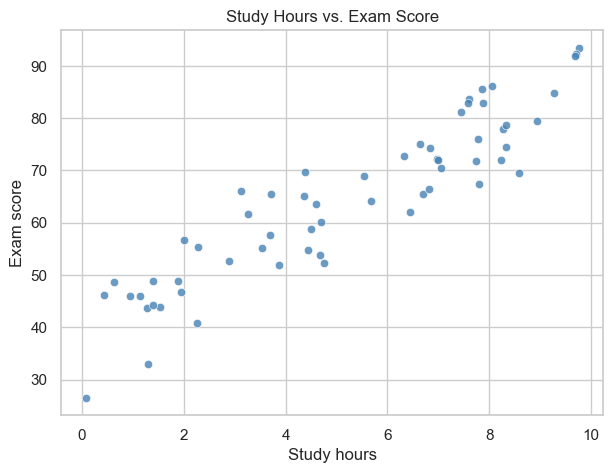

In [6]:
rng = np.random.default_rng(42)
n = 60
study_hours = rng.uniform(0, 10, n)
# True relationship: score = 5*hours + 40, plus noise -- we KNOW the ground truth here on purpose,
# so we can check whether our fitted line recovers it.
exam_score = 5 * study_hours + 40 + rng.normal(0, 8, n)
exam_score = np.clip(exam_score, 0, 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(study_hours, exam_score, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Study hours')
ax.set_ylabel('Exam score')
ax.set_title('Study Hours vs. Exam Score')
plt.show()

### 1.2 -- Fitting by Hand: the Normal Equation

In [7]:
# The normal equation solves for (w, b) directly: stack a column of 1s onto X so the intercept
# becomes just another weight, then solve the least-squares system in one shot.
X_design = np.column_stack([np.ones(n), study_hours])   # shape (n, 2): [1, hours]
beta, *_ = np.linalg.lstsq(X_design, exam_score, rcond=None)
b_hand, w_hand = beta[0], beta[1]

print(f'Normal equation solution:  score = {w_hand:.3f} * hours + {b_hand:.3f}')
print(f'(true relationship was:    score = 5.000 * hours + 40.000)')

Normal equation solution:  score = 4.958 * hours + 38.560
(true relationship was:    score = 5.000 * hours + 40.000)


### 1.3 -- Fitting by Hand: Gradient Descent

In [8]:
# Gradient descent: start with a random guess for (w, b), then repeatedly step in the direction
# that reduces MSE. The gradient of MSE with respect to w and b has a clean closed form -- we use
# it directly rather than a numerical approximation.
def gradient_descent(x, y, lr=0.01, n_iters=1000):
    w, b = 0.0, 0.0
    n = len(x)
    cost_history = []
    for i in range(n_iters):
        y_pred = w * x + b
        error = y_pred - y
        cost = np.mean(error ** 2)
        cost_history.append(cost)
        # partial derivatives of MSE w.r.t. w and b
        dw = (2 / n) * np.sum(error * x) # dL / dw = dL/ dy * dy/dw = 2 * 1/n * sum(y_pred - y) * x
        db = (2 / n) * np.sum(error)
        w -= lr * dw
        b -= lr * db
    return w, b, cost_history

# Feature scaling matters a LOT for gradient descent's convergence speed -- without it, one
# direction of the cost surface is much steeper than the other and the descent zig-zags badly.
hours_scaled = (study_hours - study_hours.mean()) / study_hours.std()
w_scaled, b_scaled, cost_history = gradient_descent(hours_scaled, exam_score, lr=0.1, n_iters=500)

# Convert the fitted line back from scaled units to the original hours scale, so it's comparable
# to the normal-equation result above.
w_gd = w_scaled / study_hours.std()
b_gd = b_scaled - w_scaled * study_hours.mean() / study_hours.std()

print(f'Gradient descent solution: score = {w_gd:.3f} * hours + {b_gd:.3f}')
print(f'Normal equation solution:  score = {w_hand:.3f} * hours + {b_hand:.3f}')
print('Both roads converge on (nearly) the same line.')

Gradient descent solution: score = 4.958 * hours + 38.560
Normal equation solution:  score = 4.958 * hours + 38.560
Both roads converge on (nearly) the same line.


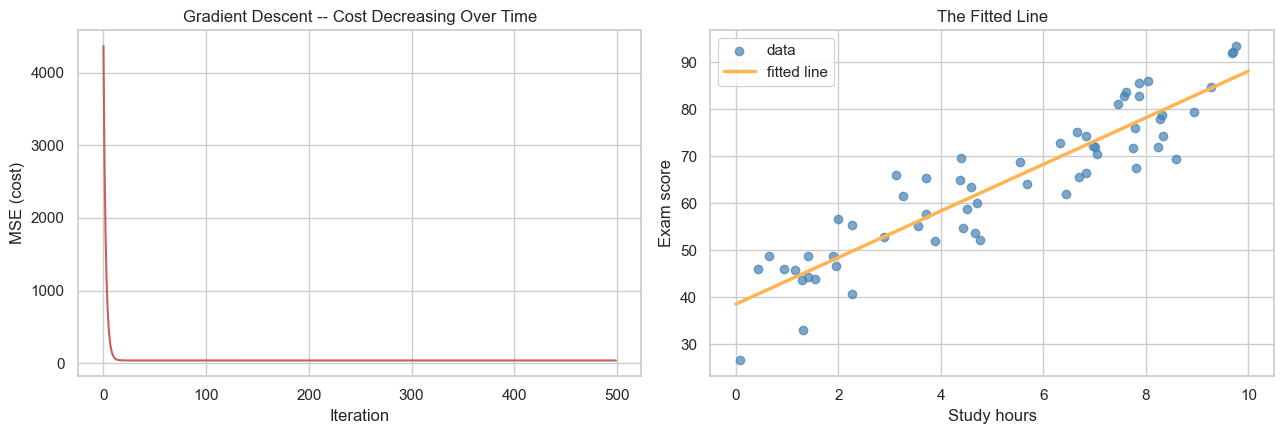

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(cost_history, color='indianred')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE (cost)')
axes[0].set_title('Gradient Descent -- Cost Decreasing Over Time')

axes[1].scatter(study_hours, exam_score, color='steelblue', alpha=0.7, label='data')
x_line = np.linspace(0, 10, 50)
axes[1].plot(x_line, w_hand * x_line + b_hand, color='#ffb454', linewidth=2.5, label='fitted line')
axes[1].set_xlabel('Study hours')
axes[1].set_ylabel('Exam score')
axes[1].set_title('The Fitted Line')
axes[1].legend()
plt.tight_layout()
plt.show()

**Watch the left panel's shape** -- a fast drop, then a long, flattening tail. That flattening
*is* convergence: each step is improving the fit less and less, which is exactly why gradient
descent needs a stopping rule (a fixed number of iterations, or "stop when cost barely changes")
rather than running forever.

### 1.4 -- The Same Fit, the sklearn Way

In [10]:
# Same data, same underlying math (sklearn's LinearRegression uses the normal-equation / SVD route
# internally) -- but now it's two lines of code instead of a hand-rolled solver.
X = study_hours.reshape(-1, 1)   # sklearn expects a 2D array of shape (n_samples, n_features)
y = exam_score

model = LinearRegression()
model.fit(X, y)

print(f'sklearn solution:         score = {model.coef_[0]:.3f} * hours + {model.intercept_:.3f}')
print(f'Normal equation (by hand): score = {w_hand:.3f} * hours + {b_hand:.3f}')
print('Identical, as expected -- .coef_ and .intercept_ ARE w and b.')

sklearn solution:         score = 4.958 * hours + 38.560
Normal equation (by hand): score = 4.958 * hours + 38.560
Identical, as expected -- .coef_ and .intercept_ ARE w and b.


---
## Part 2 -- Multiple Linear Regression: a Realistic Housing Dataset

One feature was for building intuition. Real problems have several features, mixed types, and
some deliberate messiness -- including a touch of built-in multicollinearity we'll come back to
in Part 5.

### 2.1 -- Generate the Dataset

In [12]:
rng = np.random.default_rng(7)
n = 500

# area is the "root" feature; bedrooms is DERIVED from it with noise -- built-in multicollinearity,
# on purpose, the way real housing data behaves (bigger houses usually have more bedrooms).
area_sqft = rng.normal(1800, 550, n).clip(450, 4200)
bedrooms = np.round(area_sqft / 650 + rng.normal(0, 0.6, n)).clip(1, 6).astype(int)
bathrooms = np.round(bedrooms * 0.75 + rng.normal(0, 0.5, n)).clip(1, 5).astype(int)
age_years = rng.uniform(0, 60, n)
distance_to_city_km = rng.exponential(8, n).clip(0.5, 45)
neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], n, p=[0.3, 0.5, 0.2])

neighborhood_premium = np.select(
    [neighborhood == 'Downtown', neighborhood == 'Suburb'],
    [45000, 15000], default=0,
)

price = (
    120 * area_sqft
    + 8000 * bedrooms
    - 900 * age_years
    - 1500 * distance_to_city_km
    + neighborhood_premium
    + 20000
    + rng.normal(0, 25000, n)
).clip(40000, None)

housing = pd.DataFrame({
    'area_sqft': area_sqft.round(0),
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age_years.round(1),
    'distance_to_city_km': distance_to_city_km.round(2),
    'neighborhood': neighborhood,
    'price': price.round(0),
})

print('Dataset ready:', housing.shape)
housing.head()

Dataset ready: (500, 7)


,area_sqft,bedrooms,bathrooms,age_years,distance_to_city_km,neighborhood,price
0,1801.0,3,2,41.3,0.50,Rural,201495.0
1,1964.0,2,2,27.1,20.30,Rural,186050.0
2,1649.0,2,1,11.3,4.48,Rural,203339.0
3,1310.0,3,3,58.0,2.58,Rural,142117.0
4,1550.0,3,2,28.0,2.37,Suburb,209585.0


### 2.2 -- Quick EDA

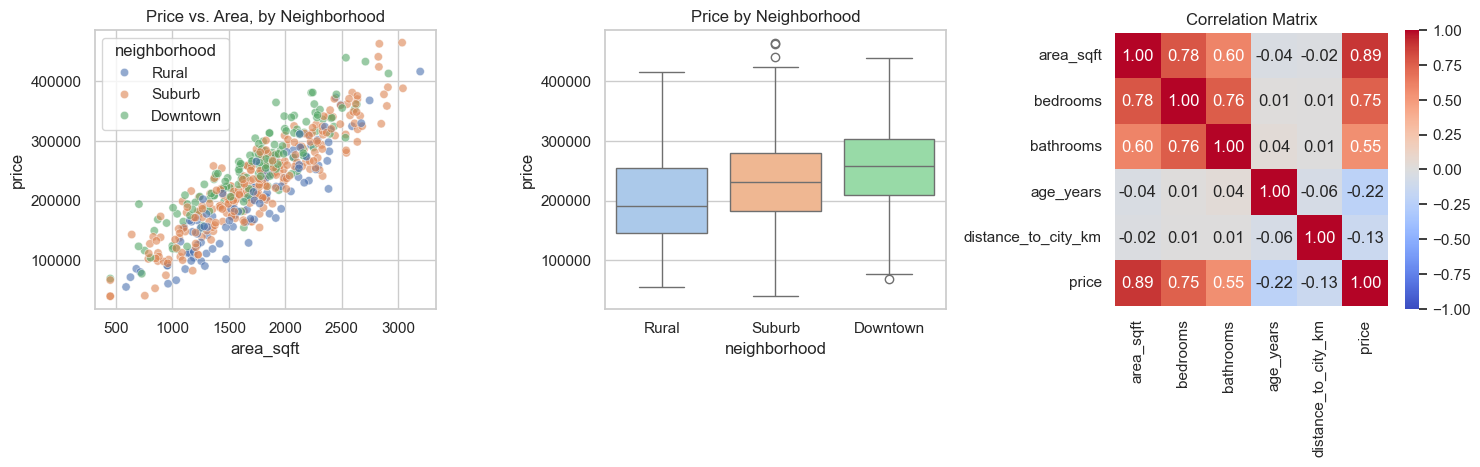

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.scatterplot(data=housing, x='area_sqft', y='price', hue='neighborhood', ax=axes[0], alpha=0.6)
axes[0].set_title('Price vs. Area, by Neighborhood')

sns.boxplot(data=housing, x='neighborhood', y='price', hue='neighborhood', legend=False, ax=axes[1], palette='pastel')
axes[1].set_title('Price by Neighborhood')

corr = housing[['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km', 'price']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2], square=True)
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

**Already visible in the heatmap:** `area_sqft` and `bedrooms` correlate strongly with each other,
not just with `price` -- the multicollinearity we built in on purpose. Keep this in mind; Part 5
measures it properly with VIF.

### 2.3 -- Preprocess and Split

In [14]:
feature_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km', 'neighborhood']
X = housing[feature_cols]
y = housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km']
categorical_features = ['neighborhood']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features),
])
# drop='first' here (unlike the churn capstone's handle_unknown='ignore') -- with a LINEAR model,
# keeping all one-hot columns plus an intercept is redundant (perfectly collinear): one category's
# effect is always relative to a baseline. Dropping the first column makes that baseline explicit.

lin_pipe = Pipeline([('preprocess', preprocessor), ('model', LinearRegression())])
lin_pipe.fit(X_train, y_train)

print('Model trained.')
print(f'Train R²: {lin_pipe.score(X_train, y_train):.3f}   Test R²: {lin_pipe.score(X_test, y_test):.3f}')

Model trained.
Train R²: 0.903   Test R²: 0.910


### 2.4 -- Interpreting the Coefficients

            feature   coefficient
          area_sqft  59914.637228
 neighborhood_Rural -48301.075955
neighborhood_Suburb -23530.212504
          age_years -15335.204027
           bedrooms  11366.608506
distance_to_city_km -10317.813222
          bathrooms  -1465.564900


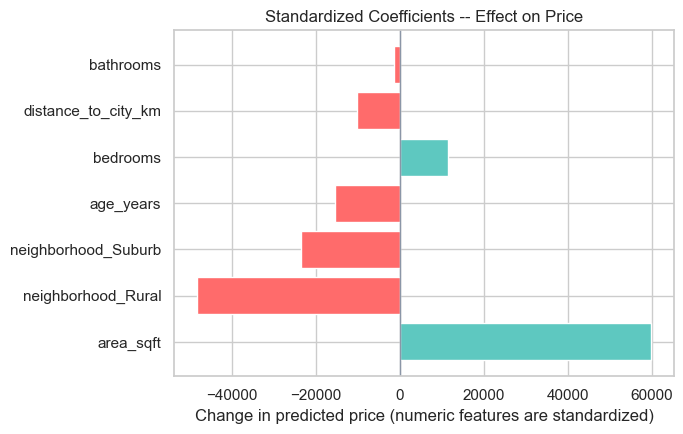

In [15]:
# Pull feature names back out, in the same order the ColumnTransformer produced them.
feature_names = (numeric_features +
                  list(lin_pipe.named_steps['preprocess']
                       .named_transformers_['cat'].get_feature_names_out(categorical_features)))
coefficients = lin_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients}) \
             .sort_values('coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#5ec8c0' if c > 0 else '#ff6b6b' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='#8b96a7', linewidth=1)
ax.set_title('Standardized Coefficients -- Effect on Price')
ax.set_xlabel('Change in predicted price (numeric features are standardized)')
plt.tight_layout()
plt.show()

**Because the numeric features were standardized first, these bars ARE directly comparable** --
`area_sqft` clearly dominates, matching how it was built into the data generator above. The
one-hot columns are the exception: they're still in "dollars relative to the dropped baseline
category," not standard-deviation units, since one-hot columns are already 0/1 and standardizing
them wouldn't mean anything.

---
## Part 3 -- Evaluation Metrics: MSE, RMSE, MAE, R²

In [16]:
y_pred_train = lin_pipe.predict(X_train)
y_pred_test = lin_pipe.predict(X_test)

def report_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:>6}  |  RMSE: ${rmse:,.0f}   MAE: ${mae:,.0f}   R²: {r2:.3f}')
    return rmse, mae, r2

report_metrics(y_train, y_pred_train, 'Train')
report_metrics(y_test, y_pred_test, 'Test')

 Train  |  RMSE: $23,695   MAE: $18,892   R²: 0.903
  Test  |  RMSE: $25,087   MAE: $20,091   R²: 0.910


(np.float64(25087.020407494532), 20090.933652529136, 0.9104709060440647)

**Read the train-vs-test gap, not just the test number in isolation.** A small gap (as here) means
the model generalizes about as well on new houses as it did on training data -- a large gap would
be the overfitting picture from Lecture 01, showing up in real numbers instead of a diagram.
`RMSE` is in dollars, directly interpretable as "typical prediction error"; `MAE` tells the same
story but is less swayed by a handful of very expensive outlier houses.

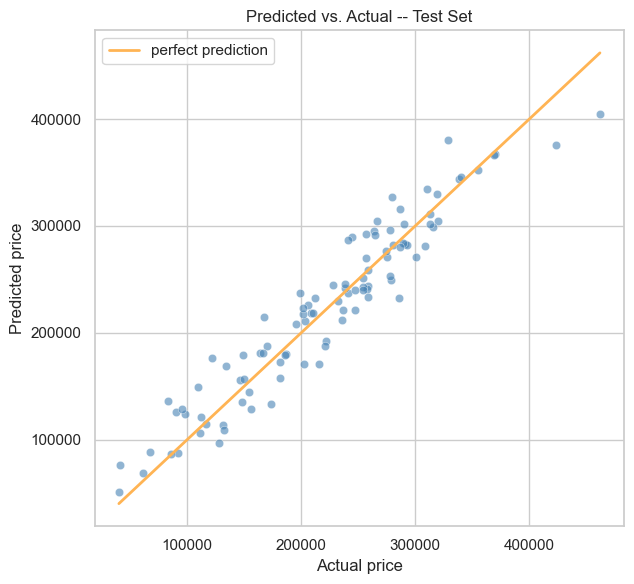

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolor='white', linewidth=0.4)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color='#ffb454', linewidth=2, label='perfect prediction')
ax.set_xlabel('Actual price')
ax.set_ylabel('Predicted price')
ax.set_title('Predicted vs. Actual -- Test Set')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 4 -- Residual Diagnostics: Checking the L.I.N.E. Assumptions

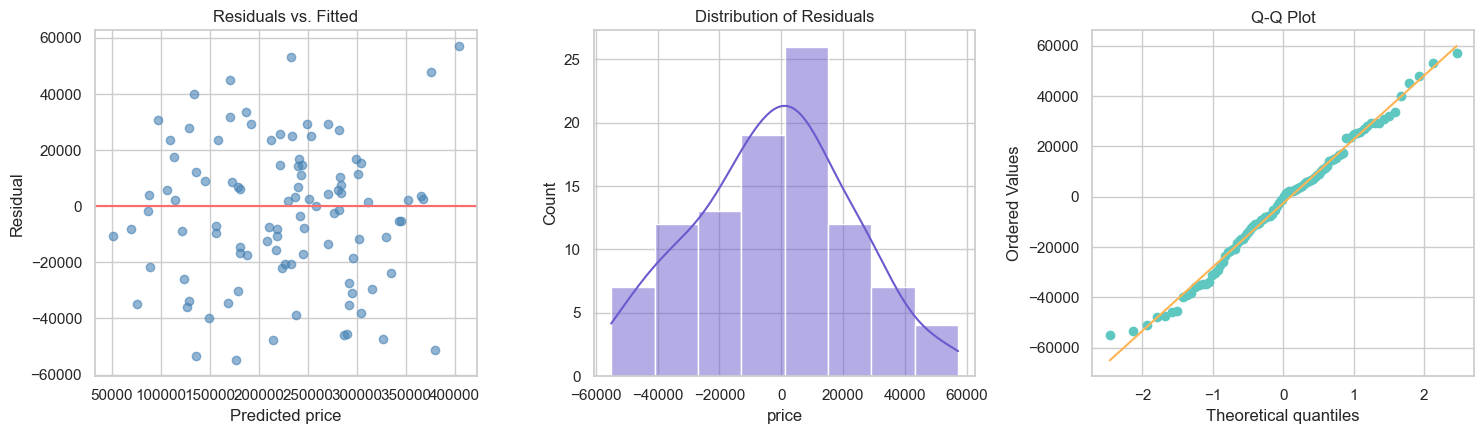

In [18]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Residuals vs. fitted -- checks Linearity and Equal Variance (homoscedasticity)
axes[0].scatter(y_pred_test, residuals, alpha=0.6, color='steelblue')
axes[0].axhline(0, color='#ff6b6b', linewidth=1.5)
axes[0].set_xlabel('Predicted price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Fitted')

# 2. Histogram of residuals -- checks Normality
sns.histplot(residuals, kde=True, ax=axes[1], color='slateblue')
axes[1].set_title('Distribution of Residuals')

# 3. Q-Q plot -- the more rigorous check for Normality: if residuals were perfectly normal, these
# points would fall on the diagonal line.
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot')
axes[2].get_lines()[0].set_markerfacecolor('#5ec8c0')
axes[2].get_lines()[0].set_markeredgecolor('#5ec8c0')
axes[2].get_lines()[1].set_color('#ffb454')

plt.tight_layout()
plt.show()

**What to look for in each panel:** residuals vs. fitted should look like a random horizontal
band with no funnel shape (equal variance) and no curve (linearity); the histogram should look
roughly bell-shaped; the Q-Q plot's points should track the diagonal reference line closely,
especially in the middle -- tails drifting off the line are common and usually not fatal on their
own. On this dataset, all three come back clean, which matches the housing generator's actual
linear-plus-noise construction above.

---
## Part 5 -- Multicollinearity: Computing VIF by Hand
No `statsmodels` needed -- VIF is defined entirely in terms of ordinary linear regression, so
plain scikit-learn computes it directly.

In [14]:
def compute_vif(df, features):
    # For each feature, regress it on all the OTHER features and record how well they predict it
    # (R^2). VIF = 1 / (1 - R^2) -- as R^2 approaches 1 (this feature is fully explained by the
    # others), VIF blows up toward infinity.
    vifs = []
    for feature in features:
        others = [f for f in features if f != feature]
        X_others = df[others].values
        y_target = df[feature].values
        r2 = LinearRegression().fit(X_others, y_target).score(X_others, y_target)
        vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
        vifs.append({'feature': feature, 'VIF': vif})
    return pd.DataFrame(vifs).sort_values('VIF', ascending=False)

numeric_only = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km']
vif_df = compute_vif(housing, numeric_only)
print(vif_df.to_string(index=False))

            feature      VIF
           bedrooms 3.939123
          area_sqft 2.606958
          bathrooms 2.387116
          age_years 1.012200
distance_to_city_km 1.005686


**Reading the table:** conventionally, `VIF > 5` deserves a look and `VIF > 10` is a real problem.
`bedrooms`, `area_sqft`, and `bathrooms` all sit in the 2-4 range here -- noticeably higher than
`age_years` and `distance_to_city_km`, which is exactly the overlap we built into the data generator
(both derived from `area_sqft`), but not yet severe enough to call an emergency. This is a realistic
outcome, not a worst case: **moderate multicollinearity like this is common** and mostly means
"don't over-interpret the individual split between `bedrooms` and `bathrooms`'s coefficients" rather
than "the model is broken." If VIF had come back above 10, that would be the point to seriously
consider dropping or combining one of the overlapping features -- exactly what Feature Selection
(next lecture) gives you formal tools to decide.

---
## Part 6 -- Polynomial Regression: When a Line Isn't Enough

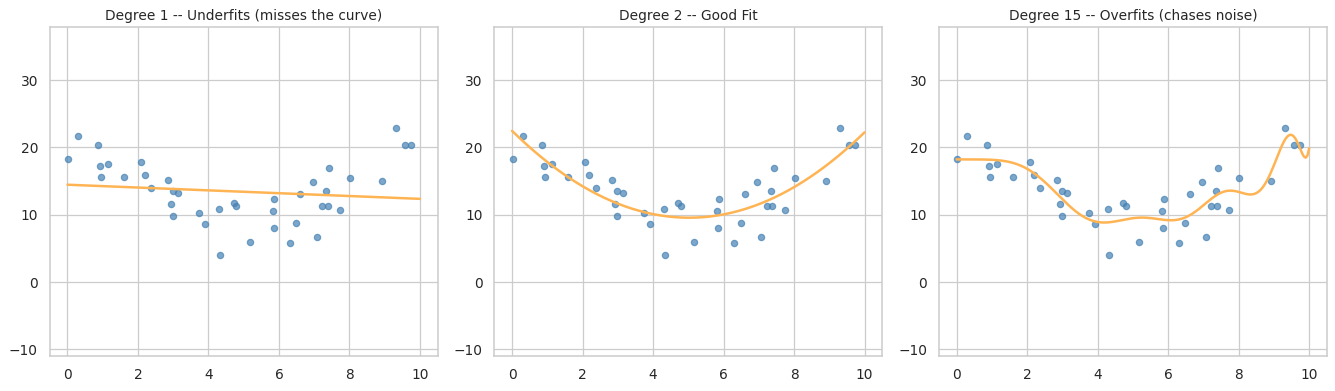

In [15]:
# A relationship with real curvature -- a straight line will systematically miss it no matter how
# it's tilted.
rng = np.random.default_rng(3)
x_curve = np.sort(rng.uniform(0, 10, 40))
y_curve = 0.5 * (x_curve - 5) ** 2 + rng.normal(0, 2.5, 40) + 10
X_curve = x_curve.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
degrees = [1, 2, 15]
titles = ['Degree 1 -- Underfits (misses the curve)', 'Degree 2 -- Good Fit', 'Degree 15 -- Overfits (chases noise)']

x_plot = np.linspace(0, 10, 200).reshape(-1, 1)

for ax, degree, title in zip(axes, degrees, titles):
    poly_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('model', LinearRegression()),
    ])
    poly_pipe.fit(X_curve, y_curve)
    y_plot = poly_pipe.predict(x_plot)

    ax.scatter(x_curve, y_curve, color='steelblue', alpha=0.7, s=25)
    ax.plot(x_plot, y_plot, color='#ffb454', linewidth=2)
    ax.set_ylim(y_curve.min() - 15, y_curve.max() + 15)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

**This is Lecture 01's underfit/good-fit/overfit picture, produced by one literal hyperparameter**
-- `degree`. It's `PolynomialFeatures` generating `x²`, `x³`, … up to `x¹⁵` as new columns, and
plain `LinearRegression` fitting a (very flexible) straight line through *that* expanded feature
space. Same algorithm throughout -- only the input features changed.

---
## Part 7 -- Regularization: Ridge and Lasso Fight the Overfitting Above

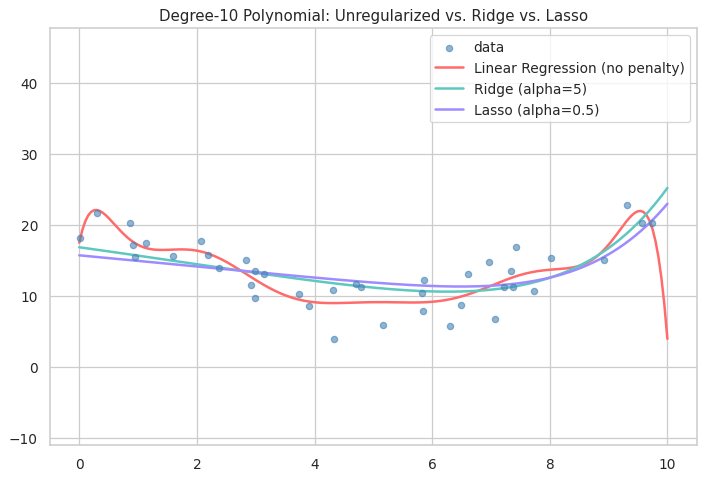

In [16]:
# Fit degree-10 polynomial features with three different models: plain LinearRegression (no
# penalty), Ridge (L2 penalty), and Lasso (L1 penalty) -- same features, different cost functions.
degree = 10
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X_curve)
X_poly_scaled = StandardScaler().fit_transform(X_poly)   # regularization is scale-sensitive -- always scale first

models = {
    'Linear Regression (no penalty)': LinearRegression(),
    'Ridge (alpha=5)': Ridge(alpha=5),
    'Lasso (alpha=0.5)': Lasso(alpha=0.5, max_iter=10000),
}

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(x_curve, y_curve, color='steelblue', alpha=0.6, s=25, label='data', zorder=5)

x_plot_poly = StandardScaler().fit(X_poly).transform(poly.transform(x_plot))
colors = {'Linear Regression (no penalty)': '#ff6b6b', 'Ridge (alpha=5)': '#5ec8c0', 'Lasso (alpha=0.5)': '#9d8cff'}

coef_comparison = {}
for name, mdl in models.items():
    mdl.fit(X_poly_scaled, y_curve)
    y_plot = mdl.predict(x_plot_poly)
    ax.plot(x_plot, y_plot, label=name, color=colors[name], linewidth=2)
    coef_comparison[name] = mdl.coef_

ax.set_ylim(y_curve.min() - 15, y_curve.max() + 25)
ax.legend()
ax.set_title(f'Degree-{degree} Polynomial: Unregularized vs. Ridge vs. Lasso')
plt.tight_layout()
plt.show()

In [17]:
# Compare coefficient magnitudes directly -- this is where "regularization shrinks coefficients"
# stops being an abstract claim.
coef_table = pd.DataFrame(coef_comparison, index=[f'x^{i}' for i in range(degree + 1)]).round(2)
print(coef_table)
print()
n_zeroed = (coef_table['Lasso (alpha=0.5)'] == 0).sum()
print(f"Lasso drove {n_zeroed} of {degree + 1} coefficients to EXACTLY zero -- effectively removing those terms.")

      Linear Regression (no penalty)  Ridge (alpha=5)  Lasso (alpha=0.5)
x^0                             0.00             0.00               0.00
x^1                           110.34            -3.19              -2.18
x^2                         -3179.38            -0.70              -0.00
x^3                         33897.42             0.50               0.00
x^4                       -191618.48             0.94               0.00
x^5                        643959.19             1.00               0.00
x^6                      -1351518.28             0.87               0.00
x^7                       1789038.87             0.68               3.01
x^8                      -1451310.82             0.47               0.00
x^9                        658678.36             0.27               0.00
x^10                      -128057.52             0.08               0.00

Lasso drove 9 of 11 coefficients to EXACTLY zero -- effectively removing those terms.


**The unregularized degree-10 fit visibly wiggles to chase noise near the edges of the data --
exactly the high-variance picture from Lecture 01.** Ridge pulls every coefficient toward zero and
produces a visibly smoother curve without eliminating any term outright. Lasso goes further,
zeroing several coefficients out completely -- it didn't just shrink the model, it **selected** a
smaller one. That's the exact mechanism Feature Selection (next lecture) builds on.

---
## Part 8 -- Full Workflow Recap: Comparing Models Honestly on the Housing Data
Same shape as the capstone's model comparison: cross-validate every candidate on the *same* folds,
then evaluate the winner once, on the untouched test set.

In [18]:
candidates = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=100)': Lasso(alpha=100, max_iter=10000),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, mdl in candidates.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', mdl)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    results.append({'model': name, 'mean_r2': scores.mean(), 'std': scores.std()})

results_df = pd.DataFrame(results).sort_values('mean_r2', ascending=False)
print(results_df)

               model   mean_r2       std
1  Ridge (alpha=1.0)  0.891135  0.035441
0  Linear Regression  0.891132  0.035542
2  Lasso (alpha=100)  0.891089  0.035646


In [19]:
best_name = results_df.iloc[0]['model']
print(f'Selected model: {best_name}')

final_pipe = Pipeline([('preprocess', preprocessor), ('model', candidates[best_name])])
final_pipe.fit(X_train, y_train)

y_pred_final = final_pipe.predict(X_test)
report_metrics(y_test, y_pred_final, 'Test')

Selected model: Ridge (alpha=1.0)
  Test  |  RMSE: $25,102   MAE: $20,134   R²: 0.910


On this dataset the three models land in nearly the same place -- the housing generator's
underlying relationship really is close to linear with modest noise, so there's little overfitting
for regularization to fix. That itself is a useful, realistic result: **regularization helps most
when a model is genuinely at risk of overfitting** (many features, limited data, strong
multicollinearity) -- not a guaranteed improvement every time you reach for it, as Part 7's
degree-10 polynomial example was deliberately built to need.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **Simple regression** | Normal equation | `np.linalg.lstsq()` on a design matrix with a column of 1s |
| | Gradient descent | Iteratively step `(w, b)` opposite the cost gradient; scale features first |
| | scikit-learn | `LinearRegression().fit(X, y)` -- `.coef_` and `.intercept_` are `w` and `b` |
| **Multiple regression** | Mixed-type preprocessing | `ColumnTransformer` + `StandardScaler` + `OneHotEncoder(drop='first')` |
| | Interpreting coefficients | Standardize numeric features first to compare magnitudes fairly |
| **Evaluation** | Metrics | `mean_squared_error`, `mean_absolute_error`, `r2_score` -- always on the test set |
| **Diagnostics** | L.I.N.E. checks | Residuals-vs-fitted plot, histogram, `scipy.stats.probplot` (Q-Q plot) |
| **Multicollinearity** | VIF | Regress each feature on the rest; `VIF = 1 / (1 - R²)`; watch for `VIF > 5-10` |
| **Nonlinearity** | Polynomial features | `PolynomialFeatures(degree=...)` + `LinearRegression` -- still linear in the weights |
| **Regularization** | Ridge / Lasso | `Ridge(alpha=)` shrinks smoothly; `Lasso(alpha=)` can zero coefficients out entirely |
| **Model selection** | Honest comparison | `cross_val_score` on the *same* folds for every candidate before touching the test set |

---

**Next lecture:** Feature Selection returns to VIF, Lasso's automatic zeroing, and adds formal
methods for deciding which features a model should be allowed to see in the first place.